# UMAP with DBSCAN Clustering and Evaluation

This notebook applies UMAP dimensionality reduction followed by DBSCAN clustering to identify patient subpopulations.

The final UMAP and DBSCAN parameters were selected in the separate hyperparameter tuning notebook and are written directly in this notebook.

The workflow includes:

1. Load the prepared scaled clustering dataset.
2. Create a two-dimensional UMAP representation.
3. Apply DBSCAN using the selected parameters.
4. Evaluate the clustering quality.
5. Compare the clustering results with Ju and Dubin.
6. Compare clinical outcomes across clusters.
7. Evaluate ICU survival across clusters.
8. Examine the clinical features that distinguish the clusters.
9. Save the essential results and plots.

## Setup and Data

### Import Required Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# UMAP dimensionality reduction
from umap import UMAP

# DBSCAN clustering
from sklearn.cluster import DBSCAN

# Internal clustering evaluation
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Survival analysis
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

#### Observation :
- Imports all libraries needed for data handling, visualization, UMAP, DBSCAN clustering, cluster evaluation, and survival analysis.
- The three clustering metrics—Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score—are included to evaluate how clearly the patient groups are separated.
- Kaplan-Meier analysis and the log-rank test are imported to compare survival outcomes across the identified patient clusters.
- Overall, this block correctly prepares the analytical environment for identifying and clinically evaluating sepsis patient subgroups using UMAP and DBSCAN.

### Set Plot Style

In [2]:
# Apply a clean visual style to all plots
sns.set_theme(style="whitegrid")

#### Observation :
- Applies Seaborn’s `whitegrid` theme to keep all visualizations consistent and easy to read.
- The grid-based style makes patterns, cluster separation, and differences between patient groups easier to interpret visually.
- Setting the theme once ensures that the same plotting style is automatically used throughout the notebook.
- Overall, this block improves the clarity and consistency of the visual analysis without affecting the underlying data or clustering results.

### Set Project Folder Paths

In [3]:
# Move two levels upward to reach the project root
ROOT = Path.cwd().parents[1]

# Original eICU tables
DATA_DIR = ROOT / "data"

# Prepared clustering dataset
DATASET_DIR = (
    ROOT
    / "results"
    / "module_2"
    / "dataset_creation"
)

# Results produced by this notebook
RESULTS_DIR = (
    ROOT
    / "results"
    / "module_2"
    / "umap_dbscan"
)

# Plots produced by this notebook
PLOTS_DIR = (
    ROOT
    / "plots"
    / "module_2"
    / "umap_dbscan"
)

# Create folders if they do not already exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Dataset folder:", DATASET_DIR)
print("Results folder:", RESULTS_DIR)
print("Plots folder:", PLOTS_DIR)

Project root: C:\Users\samsa\Documents\ICU Clustering
Dataset folder: C:\Users\samsa\Documents\ICU Clustering\results\module_2\dataset_creation
Results folder: C:\Users\samsa\Documents\ICU Clustering\results\module_2\umap_dbscan
Plots folder: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\umap_dbscan


#### Observation :
- Defines the main project, data, results, and plot directory paths using `Path`, which keeps file handling organized and platform-independent.
- Separates the prepared clustering dataset from the UMAP-DBSCAN outputs and visualizations, making the workflow easier to manage and reproduce.
- Automatically creates the required results and plots folders if they do not already exist.
- Overall, this block establishes a clear folder structure so that all sepsis clustering inputs, outputs, and figures are stored in the correct locations.

### Load the Scaled Clustering Dataset

In [4]:
# Final scaled clustering dataset
SCALED_DATA_PATH = (
    DATASET_DIR / "feature_data_scaled.csv"
)

# Saved list of clustering features
FEATURE_NAMES_PATH = (
    DATASET_DIR / "clustering_feature_names.csv"
)

# Load the data
scaled_df = pd.read_csv(SCALED_DATA_PATH)

# Load clustering feature names
feature_names_df = pd.read_csv(FEATURE_NAMES_PATH)

print("Scaled dataset shape:", scaled_df.shape)

scaled_df.head()

Scaled dataset shape: (7648, 81)


,patientunitstayid,age,gender,admissionheight,admissionweight,min_BUN,min_Hgb,min_WBC x 1000,min_anion gap,min_bicarbonate,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
0,151900,0.666667,1.0,0.271546,0.077035,0.055777,0.270588,0.028740,0.339286,0.512195,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,210208,0.472222,0.0,0.267434,0.058982,0.039841,0.476471,0.016535,0.321429,0.512195,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,179269,0.888889,1.0,0.254770,0.061000,0.183267,0.400000,0.023228,0.482143,0.439024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,172764,0.736111,1.0,0.275658,0.075577,0.039841,0.700000,0.073622,0.535714,0.317073,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,166175,0.583333,0.0,0.304934,0.100695,0.023904,0.535294,0.043701,0.428571,0.414634,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


#### Observation :
- Loads the scaled sepsis dataset and the saved list of clustering feature names from the prepared dataset folder.
- The scaled dataset contains $7,648$ ICU stays and $81$ columns, confirming that a substantial patient cohort is available for clustering.
- The displayed sample shows that continuous clinical variables have been scaled to comparable ranges, while categorical variables are represented using binary values.
- Overall, this block successfully loads the processed patient data required for the subsequent UMAP dimensionality reduction and DBSCAN clustering.

### Load the Clustering Feature Names

In [5]:
# The first column contains the clustering feature names
feature_cols = (
    feature_names_df.iloc[:, 0]
    .astype(str)
    .tolist()
)

print(
    "Number of saved clustering features:",
    len(feature_cols)
)

feature_cols[:10]

Number of saved clustering features: 80


['age',
 'gender',
 'admissionheight',
 'admissionweight',
 'min_BUN',
 'min_Hgb',
 'min_WBC x 1000',
 'min_anion gap',
 'min_bicarbonate',
 'min_chloride']

#### Observation :
- Extracts the clustering feature names from the first column of the saved feature-name file and converts them into a Python list.
- Confirms that $80$ clinical features were selected for the clustering analysis.
- The first features include variables such as age, gender, admission height, admission weight, BUN, hemoglobin, WBC, anion gap, bicarbonate, and chloride.
- Overall, this block ensures that the subsequent UMAP and DBSCAN analysis uses the exact predefined set of sepsis clustering features.

### Prepare the Clustering Matrix

In [6]:
# Unique eICU ICU-stay identifier
ID_COL = "patientunitstayid"

# Keep only features that exist in the scaled dataset
feature_cols = [
    feature
    for feature in feature_cols
    if feature in scaled_df.columns
]

# X contains only the variables used for clustering
X = scaled_df[feature_cols].copy()

print("Patients:", len(X))
print("Clustering features:", X.shape[1])

Patients: 7648
Clustering features: 80


#### Observation :
- Defines `patientunitstayid` as the unique identifier for each ICU stay.
- Keeps only the saved clustering features that are actually present in the scaled dataset, preventing errors from missing columns.
- Creates the final clustering matrix `X`, containing only the variables that will be used by UMAP and DBSCAN.
- The matrix contains $7,648$ patients and $80$ clustering features, confirming that all expected features are available for the analysis.

### Verify the Clustering Matrix

In [7]:
# Check that each ICU stay appears only once
print(
    "Duplicate patient IDs:",
    scaled_df[ID_COL].duplicated().sum()
)

# UMAP requires complete numerical data
print(
    "Missing values:",
    X.isna().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(X.to_numpy()).sum()
)

# The input data were Min-Max scaled
print(
    "Minimum feature value:",
    X.min().min()
)

print(
    "Maximum feature value:",
    X.max().max()
)

Duplicate patient IDs: 0
Missing values: 0
Infinite values: 0
Minimum feature value: 0.0
Maximum feature value: 1.0000000000000002


#### Observation :
- Checks the dataset for duplicate ICU stay IDs, missing values, and infinite values before applying UMAP.
- The results show $0$ duplicate patient IDs, $0$ missing values, and $0$ infinite values, confirming that the clustering matrix is clean and complete.
- Feature values range from approximately $0$ to $1$, which confirms that the input variables were successfully Min-Max scaled.
- Overall, this block verifies that the sepsis patient dataset is properly prepared and numerically valid for UMAP dimensionality reduction and DBSCAN clustering.

# UMAP Representation

### Set the Final UMAP Parameters

In [8]:
# Final parameters selected during hyperparameter tuning
UMAP_COMPONENTS = 2
UMAP_N_NEIGHBORS = 10
UMAP_MIN_DIST = 0.1

# Euclidean distance is used in the feature space
UMAP_METRIC = "euclidean"

# Fixed seed improves reproducibility
RANDOM_STATE = 42

print("UMAP dimensions:", UMAP_COMPONENTS)
print("UMAP n_neighbors:", UMAP_N_NEIGHBORS)
print("UMAP min_dist:", UMAP_MIN_DIST)
print("UMAP metric:", UMAP_METRIC)
print("Random state:", RANDOM_STATE)

UMAP dimensions: 2
UMAP n_neighbors: 10
UMAP min_dist: 0.1
UMAP metric: euclidean
Random state: 42


#### Observation :
- Sets the final UMAP hyperparameters selected during the earlier tuning process.
- Reduces the data to $2$ dimensions, which allows the patient structure to be visualized and used for DBSCAN clustering.
- Uses $10$ nearest neighbors and a minimum distance of $0.1$, emphasizing relatively local relationships between similar sepsis patients.
- Uses Euclidean distance as the similarity measure and sets `random_state = 42` to support reproducibility.
- Overall, this block defines the final UMAP configuration used to generate the low-dimensional representation of the sepsis patient population.

### Create the Two-Dimensional UMAP Representation

In [9]:
# Create the UMAP model
umap_model = UMAP(
    n_components=UMAP_COMPONENTS,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC
)

# Reduce the clustering matrix to two dimensions
umap_embedding = umap_model.fit_transform(X)

print("Original feature matrix:", X.shape)
print("UMAP representation:", umap_embedding.shape)

Original feature matrix: (7648, 80)
UMAP representation: (7648, 2)


#### Observation :
- Creates the UMAP model using the final hyperparameters selected during tuning.
- Applies UMAP to the $80$-dimensional patient feature matrix and transforms it into a $2$-dimensional representation.
- Each sepsis patient is represented by two coordinates, preserving important similarity patterns from the original clinical data.
- Overall, this block generates the low-dimensional patient representation that will be used for visualization and DBSCAN clustering.

### Create the UMAP Results Table

In [10]:
# Store patient ID and the two UMAP coordinates
umap_results = pd.DataFrame({
    ID_COL: scaled_df[ID_COL].values,
    "umap_1": umap_embedding[:, 0],
    "umap_2": umap_embedding[:, 1]
})

umap_results.head()

,patientunitstayid,umap_1,umap_2
0,151900,12.053260,7.202587
1,210208,11.614841,-2.109406
2,179269,0.955670,-2.345184
3,172764,1.228649,-2.845633
4,166175,-11.563247,6.491658


#### Observation :
- Creates a new results table containing each patient’s unique ICU stay ID and the two UMAP coordinates, `umap_1` and `umap_2`.
- Each patient is now represented by a point in the two-dimensional UMAP space instead of the original $80$ clinical features.
- Keeping the `patientunitstayid` preserves the link between each UMAP point and the original sepsis patient record.
- Overall, this block organizes the UMAP output into a structured format that can be directly used for DBSCAN clustering, visualization, and later clinical analysis.

### Plot the UMAP Representation

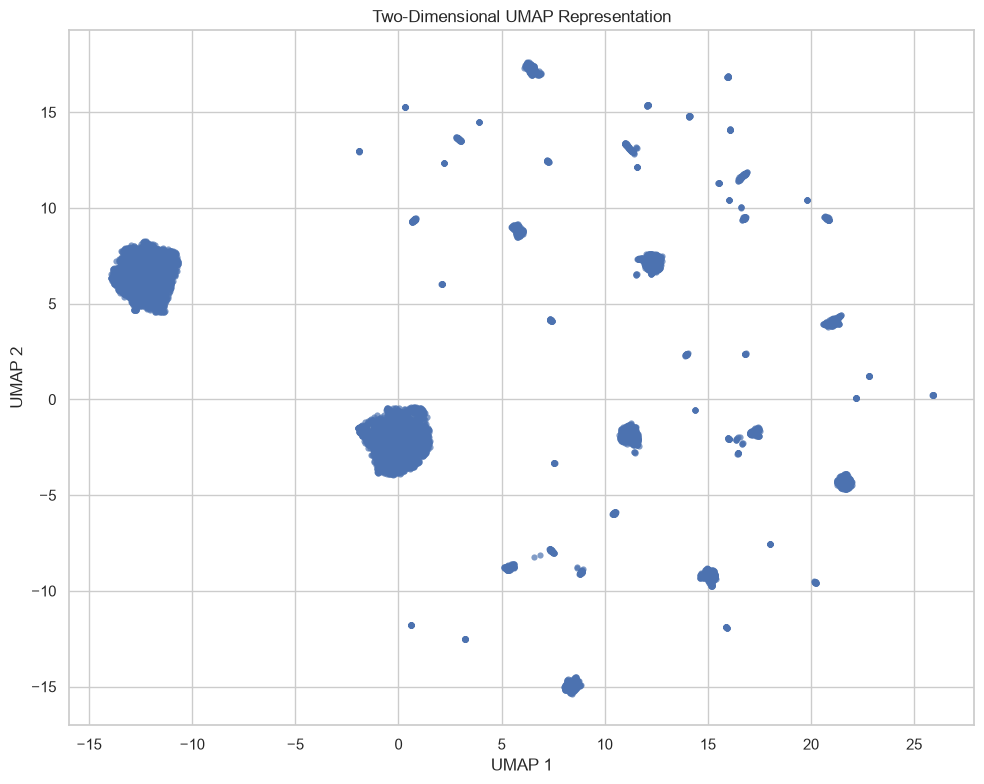

In [11]:
plt.figure(figsize=(10, 8))

# Plot the patient representation before clustering
sns.scatterplot(
    data=umap_results,
    x="umap_1",
    y="umap_2",
    s=20,
    alpha=0.7,
    linewidth=0
)

plt.title("Two-Dimensional UMAP Representation")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()

# Save the plot
plt.savefig(
    PLOTS_DIR / "umap_representation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Visualizes all $7,648$ sepsis patients in the two-dimensional UMAP space before applying DBSCAN clustering.
- Each point represents one ICU stay, and patients positioned closer together have more similar patterns across the $80$ clinical features.
- The plot helps reveal the overall structure, density, and potential subgroup patterns within the sepsis population before assigning cluster labels.
- Overall, this block provides a visual check that the UMAP transformation has produced a meaningful low-dimensional representation for subsequent DBSCAN clustering.

## DBSCAN CLustering

### Set the Final DBSCAN Parameters

In [12]:
# Final parameters selected during hyperparameter tuning
DBSCAN_EPS = 0.35
DBSCAN_MIN_SAMPLES = 50

print("DBSCAN epsilon:", DBSCAN_EPS)
print("DBSCAN min_samples:", DBSCAN_MIN_SAMPLES)

DBSCAN epsilon: 0.35
DBSCAN min_samples: 50


#### Observation :
- Defines the final DBSCAN hyperparameters selected during the earlier tuning process.
- Sets `eps = 0.35`, which determines the maximum distance between neighboring points for them to be considered part of the same local region.
- Sets `min_samples = 50`, meaning at least 50 nearby patients are required to form a dense region or cluster.
- Overall, this block establishes the final DBSCAN configuration used to identify dense sepsis patient subgroups and separate outliers in the UMAP space.

### Apply DBSCAN to the UMAP Representation

In [13]:
# Create the DBSCAN model
dbscan = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES,
    metric="euclidean"
)

# Assign every patient to a cluster
cluster_labels = dbscan.fit_predict(
    umap_embedding
)

# Add cluster labels to the UMAP results
umap_results["cluster"] = cluster_labels

umap_results.head()

,patientunitstayid,umap_1,umap_2,cluster
0,151900,12.053260,7.202587,0
1,210208,11.614841,-2.109406,1
2,179269,0.955670,-2.345184,2
3,172764,1.228649,-2.845633,2
4,166175,-11.563247,6.491658,3


#### Observation :
- Creates the DBSCAN model using the selected parameters: `eps = 0.35`, `min_samples = 50`, and Euclidean distance.
- Applies DBSCAN directly to the $2$-dimensional UMAP representation of the sepsis patients.
- Assigns each patient a cluster label, while patients that do not belong to a sufficiently dense region can be marked as outliers ($-1$).
- Adds the cluster labels to the UMAP results table, linking each ICU stay ID and UMAP coordinates with its identified patient subgroup.
- Overall, this block performs the actual density-based clustering of sepsis patients in the UMAP space.

### Summarize the Clustering Result

In [14]:
# Count actual clusters
# DBSCAN uses -1 for outliers
n_clusters = len(set(cluster_labels)) - (
    1 if -1 in cluster_labels else 0
)

# Count outliers
n_outliers = np.sum(
    cluster_labels == -1
)

# Calculate outlier percentage
outlier_percentage = (
    n_outliers / len(cluster_labels)
) * 100

print("Patients:", len(umap_results))
print("Number of clusters:", n_clusters)
print("Number of outliers:", n_outliers)

print(
    "Outlier percentage:",
    round(outlier_percentage, 2),
    "%"
)

Patients: 7648
Number of clusters: 22
Number of outliers: 525
Outlier percentage: 6.86 %


#### Observation :
- Calculates the total number of DBSCAN clusters while correctly excluding the outlier label ($-1$) from the cluster count.
- DBSCAN identifies $22$ distinct patient clusters from the $7,648$ sepsis ICU stays.
- A total of $525$ patients are classified as outliers, representing $6.86\%$ of the cohort.
- This means about $93.14\%$ of patients are assigned to a defined cluster, showing that DBSCAN captures the majority of the sepsis population within structured patient subgroups.

### Check Cluster Sizes

In [15]:
# Count patients in every cluster
cluster_distribution = (
    umap_results["cluster"]
    .value_counts()
    .sort_index()
    .rename("patients")
    .to_frame()
)

cluster_distribution

,patients
cluster,
-1,525
0,360
1,348
2,2059
3,2128
4,87
5,173
6,227
7,170


`Cluster -1` represents DBSCAN outliers

#### Observation :
- Calculates the number of patients assigned to each DBSCAN cluster, including the outlier group labeled $-1$.
- Cluster sizes vary considerably, with Cluster $3$ containing $2,128$ patients and Cluster $2$ containing $2,059$ patients, making them the two largest patient subgroups.
- Several clusters are much smaller, such as Cluster $11$ with $54$ patients, Cluster $17$ with $55$ patients, and Cluster $13$ with $57$ patients, showing that DBSCAN identifies both large and small sepsis subgroups.
- The $525$ outliers are also displayed separately, allowing the cluster distribution to be assessed without treating them as a normal patient subgroup.
- Overall, this block shows that the identified sepsis clusters are uneven in size, suggesting substantial heterogeneity within the patient population.

### Plot the UMAP DBSCAN Clusters

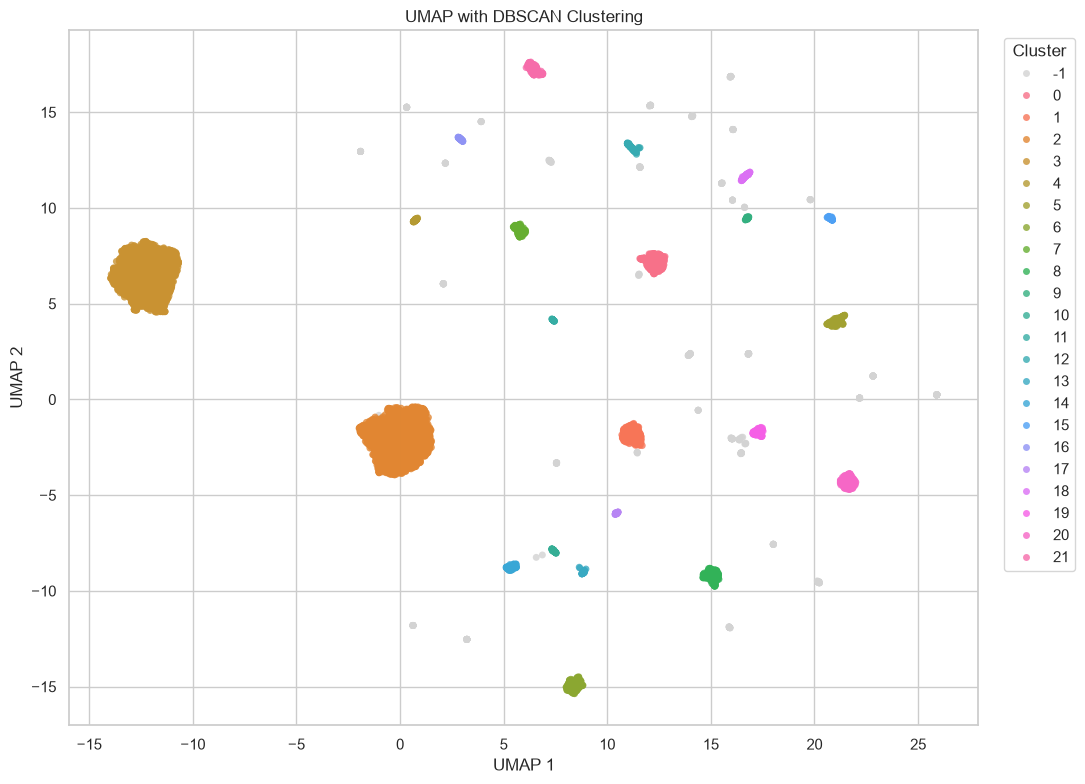

In [16]:
# Get the actual cluster numbers
normal_clusters = sorted(
    [
        cluster
        for cluster in umap_results["cluster"].unique()
        if cluster != -1
    ]
)

# Create one color for each cluster
colors = sns.color_palette(
    "husl",
    len(normal_clusters)
)

cluster_palette = dict(
    zip(normal_clusters, colors)
)

# Display DBSCAN outliers in gray
cluster_palette[-1] = "lightgray"

plt.figure(figsize=(11, 8))

# Plot patients using their DBSCAN cluster as color
sns.scatterplot(
    data=umap_results,
    x="umap_1",
    y="umap_2",
    hue="cluster",
    palette=cluster_palette,
    s=25,
    alpha=0.8,
    linewidth=0
)

plt.title("UMAP with DBSCAN Clustering")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Place the cluster legend outside the plot
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Save the plot
plt.savefig(
    PLOTS_DIR / "umap_dbscan_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Visualizes the UMAP representation after DBSCAN clustering, with each identified patient cluster shown using a different color.
- DBSCAN outliers ($-1$) are shown in light gray, making them easy to distinguish from the main patient subgroups.
- The plot allows direct assessment of the location, separation, density, and overlap of the $22$ sepsis clusters in the UMAP space.
- Overall, this block provides a clear visual confirmation of how DBSCAN has partitioned the sepsis patient population into distinct subgroups and saves the figure for later reporting.

## Internal Cluster Evaluation

### Remove DBSCAN Outliers for Evaluation

In [17]:
# Outliers are not treated as a normal cluster
evaluation_mask = (
    umap_results["cluster"] != -1
)

# Keep only clustered UMAP coordinates
X_evaluation = umap_results.loc[
    evaluation_mask,
    ["umap_1", "umap_2"]
]

# Corresponding cluster labels
labels_evaluation = umap_results.loc[
    evaluation_mask,
    "cluster"
]

print(
    "Patients used for evaluation:",
    len(X_evaluation)
)

print(
    "Clusters evaluated:",
    labels_evaluation.nunique()
)

Patients used for evaluation: 7123
Clusters evaluated: 22


#### Observation :
- Removes DBSCAN outliers ($-1$) before calculating clustering performance metrics, since outliers are not treated as a true patient cluster.
- Keeps only the UMAP coordinates and corresponding cluster labels for patients assigned to valid clusters.
- A total of $7,123$ patients are included in the cluster evaluation.
- The evaluation covers all $22$ identified sepsis patient clusters, ensuring that the clustering metrics reflect the quality of the actual patient subgroups.

### Calculate Internal Evaluation Metrics

In [18]:
# Higher Silhouette Score is better
silhouette = silhouette_score(
    X_evaluation,
    labels_evaluation
)

# Lower Davies-Bouldin Index is better
dbi = davies_bouldin_score(
    X_evaluation,
    labels_evaluation
)

# Higher Calinski-Harabasz Index is better
chi = calinski_harabasz_score(
    X_evaluation,
    labels_evaluation
)

print(
    "Silhouette Score:",
    round(silhouette, 4)
)

print(
    "Davies-Bouldin Index:",
    round(dbi, 4)
)

print(
    "Calinski-Harabasz Index:",
    round(chi, 2)
)

Silhouette Score: 0.8867
Davies-Bouldin Index: 0.0984
Calinski-Harabasz Index: 64673.27


#### Observation :
- Evaluates the quality of the identified patient clusters using Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index.
- The Silhouette Score of $0.8867$ indicates that the clusters are highly compact and well separated from one another.
- The Davies-Bouldin Index of $0.0984$ is very low, showing minimal overlap and strong separation between the sepsis patient groups.
- The Calinski-Harabasz Index of $64,673.27$ further supports strong clustering structure, with high separation between clusters compared with variation within clusters.
- Overall, all three metrics indicate that the UMAP + DBSCAN approach produced very well-defined sepsis patient subgroups.

### Compare the Replication

In [19]:
# Ju and Dubin UMAP + DBSCAN benchmark results
evaluation_summary = pd.DataFrame({

    "metric": [
        "Number of clusters",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ],

    "our_replication": [
        n_clusters,
        silhouette,
        dbi,
        chi
    ],

    "ju_dubin_paper": [
        22,
        0.84,
        0.09,
        54413.23
    ]
})

evaluation_summary.round(4)

,metric,our_replication,ju_dubin_paper
0,Number of clusters,22.0000,22.00
1,Silhouette Score,0.8867,0.84
2,Davies-Bouldin Index,0.0984,0.09
3,Calinski-Harabasz Index,64673.2695,54413.23


#### Observation :
- Compares the UMAP + DBSCAN replication results with the benchmark values reported in the Ju and Dubin study.
- Both approaches identify $22$ clusters, showing that the replication successfully reproduces the same number of sepsis patient subgroups.
- The replication achieves a higher Silhouette Score ($0.8867$ vs. $0.84$), indicating slightly stronger cluster separation.
- The Davies-Bouldin Index ($0.0984$ vs. $0.09$) is very close to the paper’s value, while the higher Calinski-Harabasz Score ($64,673.27$ vs. $54,413.23$) indicates strong clustering structure.
- Overall, the results are highly consistent with the published benchmark, supporting the reliability of the UMAP + DBSCAN replication.

## Clinical Outcome Evaluation

### Load the Required Clinical Data

In [20]:
# Load only the patient variables required for evaluation
patient = pd.read_csv(
    DATA_DIR / "patient.csv",
    usecols=[
        "patientunitstayid",
        "age",
        "unitdischargeoffset",
        "hospitaldischargeoffset",
        "unitdischargestatus",
        "hospitaldischargestatus"
    ]
)

# Load APACHE severity scores
apache = pd.read_csv(
    DATA_DIR / "apachePatientResult.csv",
    usecols=[
        "patientunitstayid",
        "apacheversion",
        "apachescore"
    ]
)

print("Patient table:", patient.shape)
print("APACHE table:", apache.shape)

Patient table: (200859, 6)
APACHE table: (297064, 3)


#### Observation :
- Loads the required patient-level clinical outcomes from the eICU `patient.csv` file, including age, ICU/hospital length of stay information, and discharge status.
- Loads APACHE severity scores from `apachePatientResult.csv` for later assessment of illness severity across the identified clusters.
- The patient table contains $200,859$ records with $6$ selected variables, while the APACHE table contains $297,064$ records with $3$ selected variables.
- Overall, this block brings in the key clinical information needed to evaluate whether the UMAP-derived sepsis clusters differ in severity, mortality, and length of stay.

### Prepare Age and Length of Stay (LOS)

In [21]:
# Create a copy before changing the patient table
outcomes = patient.copy()

# eICU stores ages above 89 as "> 89"
outcomes["age"] = outcomes["age"].replace(
    "> 89",
    "90"
)

# Convert age to numeric
outcomes["age"] = pd.to_numeric(
    outcomes["age"],
    errors="coerce"
)

# Convert ICU stay from minutes to days
outcomes["icu_los_days"] = (
    outcomes["unitdischargeoffset"] / 1440
)

# Convert hospital stay from minutes to days
outcomes["hospital_los_days"] = (
    outcomes["hospitaldischargeoffset"] / 1440
)

#### Observation :
- Creates a separate copy of the patient outcome data so the original table remains unchanged during preprocessing.
- Converts the eICU age value $\gt 89$ to $90$ and then converts the entire age column into numeric format for analysis.
- Converts ICU length of stay from minutes to days using `unitdischargeoffset`, making the measure easier to interpret clinically.
- Converts hospital length of stay from minutes to days using `hospitaldischargeoffset`.
- Overall, this block prepares the key age and length-of-stay variables for clinical comparison across the identified sepsis clusters.

### Prepare Mortality Variables

In [22]:
# ICU mortality
# Alive = 0
# Expired = 1
outcomes["icu_mortality"] = (
    outcomes["unitdischargestatus"]
    .map({
        "Alive": 0,
        "Expired": 1
    })
)

# Hospital mortality
outcomes["hospital_mortality"] = (
    outcomes["hospitaldischargestatus"]
    .map({
        "Alive": 0,
        "Expired": 1
    })
)

print("ICU mortality:")

print(
    outcomes["icu_mortality"]
    .value_counts(dropna=False)
)

print()

print("Hospital mortality:")

print(
    outcomes["hospital_mortality"]
    .value_counts(dropna=False)
)

ICU mortality:
icu_mortality
0.0    189918
1.0     10907
NaN        34
Name: count, dtype: int64

Hospital mortality:
hospital_mortality
0.0    181104
1.0     18004
NaN      1751
Name: count, dtype: int64


#### Observation :
- Converts the ICU and hospital discharge status into binary mortality variables, where Alive = $0$ and Expired = $1$.
- For ICU mortality, $10,907$ patients died and $189,918$ survived, with only $34$ missing values.
- For hospital mortality, $18,004$ patients died and $181,104$ survived, while $1,751$ records have missing mortality information.
- Overall, this block prepares standardized ICU and hospital mortality outcomes for comparing survival differences across the sepsis patient clusters.

### Prepare APACHE IVa Scores

In [23]:
# Keep only APACHE IVa scores
apache_iva = apache[
    apache["apacheversion"] == "IVa"
][
    [
        "patientunitstayid",
        "apachescore"
    ]
].copy()

# Keep one APACHE score per ICU stay
apache_iva = apache_iva.drop_duplicates(
    subset="patientunitstayid"
)

# Give the score a clearer name
apache_iva = apache_iva.rename(
    columns={
        "apachescore": "apache_iva"
    }
)

print(
    "Patients with APACHE IVa:",
    len(apache_iva)
)

Patients with APACHE IVa: 148532


#### Observation :
- Filters the APACHE dataset to retain only APACHE IVa scores, ensuring a consistent severity measure is used for all patients.
- Keeps only `patientunitstayid` and APACHE score, removing variables that are not needed for the clinical evaluation.
- Removes duplicate ICU stay IDs so that each patient stay has only one APACHE IVa severity score.
- Renames `apachescore` to `apache_iva` for clearer interpretation in the later analysis.
- A total of $148,532$ ICU stays have an available APACHE IVa score for subsequent comparison of disease severity across the sepsis clusters.

### Merge Clinical Outcomes with Cluster Assignments

In [24]:
# Combine cluster assignments with clinical outcomes
clinical_results = (
    umap_results
    .merge(
        outcomes,
        on=ID_COL,
        how="left"
    )
    .merge(
        apache_iva,
        on=ID_COL,
        how="left"
    )
)

print(
    "Patients after clinical merge:",
    len(clinical_results)
)

clinical_results.head()

Patients after clinical merge: 7648


,patientunitstayid,umap_1,umap_2,cluster,age,hospitaldischargeoffset,hospitaldischargestatus,unitdischargeoffset,unitdischargestatus,icu_los_days,hospital_los_days,icu_mortality,hospital_mortality,apache_iva
0,151900,12.053260,7.202587,0,66.0,6355,Alive,3460,Alive,2.402778,4.413194,0.0,0.0,68.0
1,210208,11.614841,-2.109406,1,52.0,8352,Alive,5478,Alive,3.804167,5.800000,0.0,0.0,49.0
2,179269,0.955670,-2.345184,2,82.0,24087,Alive,3655,Alive,2.538194,16.727083,0.0,0.0,117.0
3,172764,1.228649,-2.845633,2,71.0,10974,Alive,2077,Alive,1.442361,7.620833,0.0,0.0,NaN
4,166175,-11.563247,6.491658,3,60.0,10037,Alive,1175,Alive,0.815972,6.970139,0.0,0.0,47.0


#### Observation :
- Merges the UMAP-DBSCAN cluster assignments with the prepared patient outcomes and APACHE IVa severity scores using `patientunitstayid`.
- The merge retains all $7,648$ sepsis patients, confirming that no clustered patient records are lost during the integration step.
- Each patient record now contains the UMAP coordinates, cluster label, age, ICU and hospital length of stay, mortality outcomes, and APACHE IVa score.
- Some patients have missing APACHE IVa values, which should be considered when comparing illness severity across clusters.
- Overall, this block creates the final patient-level clinical dataset needed to evaluate the clinical characteristics and outcomes of each sepsis subgroup.

### Create the Cluster Outcome Summary

In [25]:
# Remove DBSCAN outliers from cluster interpretation
cluster_clinical = clinical_results[
    clinical_results["cluster"] != -1
].copy()

# Calculate clinical characteristics for every cluster
clinical_summary = (
    cluster_clinical
    .groupby("cluster")
    .agg(
        patients=(ID_COL, "size"),
        mean_age=("age", "mean"),
        mean_apache_iva=("apache_iva", "mean"),
        mean_icu_los=("icu_los_days", "mean"),
        mean_hospital_los=("hospital_los_days", "mean"),
        icu_mortality=("icu_mortality", "mean"),
        hospital_mortality=("hospital_mortality", "mean")
    )
    .reset_index()
)

# Calculate patient percentage
clinical_summary["patient_percentage"] = (
    clinical_summary["patients"]
    / clinical_summary["patients"].sum()
    * 100
)

# Convert mortality proportions into percentages
clinical_summary["icu_mortality"] *= 100
clinical_summary["hospital_mortality"] *= 100

# Arrange columns
clinical_summary = clinical_summary[
    [
        "cluster",
        "patients",
        "patient_percentage",
        "mean_age",
        "mean_apache_iva",
        "mean_icu_los",
        "mean_hospital_los",
        "icu_mortality",
        "hospital_mortality"
    ]
]

clinical_summary.round(2)

,cluster,patients,patient_percentage,mean_age,mean_apache_iva,mean_icu_los,mean_hospital_los,icu_mortality,hospital_mortality
0,0,360,5.05,67.24,75.53,3.95,9.16,14.44,19.83
1,1,348,4.89,67.30,75.69,4.17,10.56,14.94,19.36
2,2,2059,28.91,66.51,73.15,3.67,8.34,12.97,19.22
3,3,2128,29.88,66.33,73.57,3.99,8.71,12.55,18.90
4,4,87,1.22,64.51,73.37,4.65,10.92,14.94,19.54
5,5,173,2.43,61.27,79.81,3.95,9.83,12.14,21.43
6,6,227,3.19,67.21,73.22,4.13,8.67,10.57,21.15
7,7,170,2.39,59.53,70.68,4.29,10.47,10.00,19.41
8,8,223,3.13,66.32,72.37,3.95,8.67,11.21,17.94
9,9,65,0.91,65.22,75.70,9.08,13.86,18.46,19.05


#### Observation :
- Removes the DBSCAN outliers ($-1$) before clinically interpreting the identified sepsis clusters.
- Summarizes each of the $22$ clusters using patient count, age, APACHE IVa severity, ICU/hospital length of stay, and mortality rates.
- Clusters $2$ and $3$ dominate the cohort, containing $28.91\%$ and $29.88\%$ of clustered patients, while several other clusters represent much smaller patient subgroups.
- Important clinical differences are visible across clusters. For example, Cluster $11$ has the highest ICU mortality at $24.07\%$, while Cluster $13$ has the highest hospital mortality at $27.27\%$.

### Plot Hospital Mortality Across Clusters

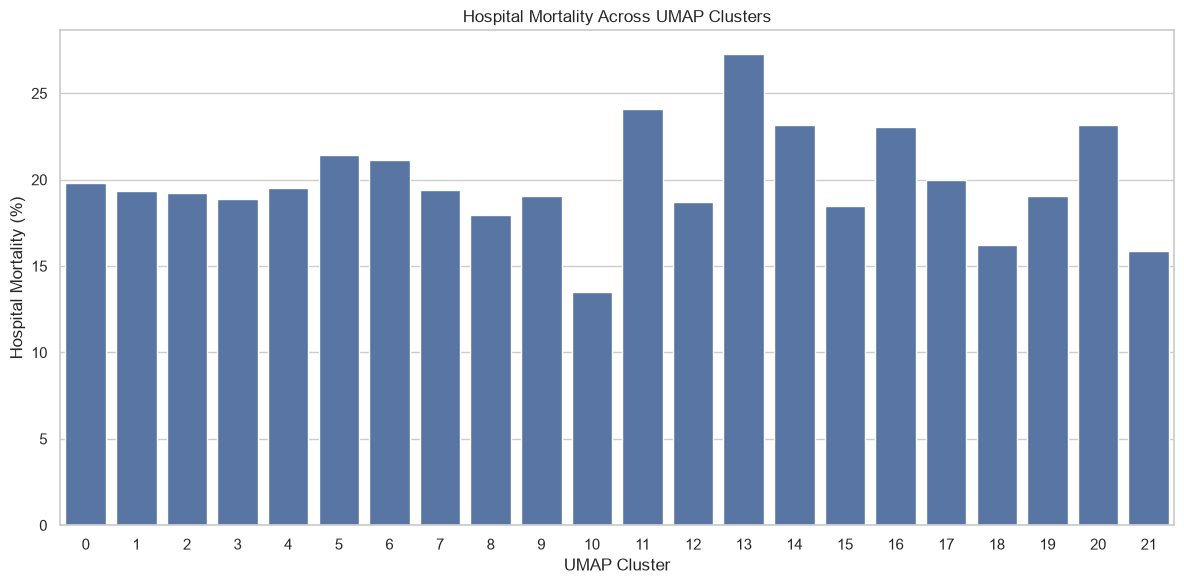

In [26]:
plt.figure(figsize=(12, 6))

# Compare hospital mortality across clusters
sns.barplot(
    data=clinical_summary,
    x="cluster",
    y="hospital_mortality",
    errorbar=None
)

plt.title(
    "Hospital Mortality Across UMAP Clusters"
)

plt.xlabel("UMAP Cluster")
plt.ylabel("Hospital Mortality (%)")

plt.tight_layout()

# Save the plot
plt.savefig(
    PLOTS_DIR / "umap_hospital_mortality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Visualizes the hospital mortality rate for each of the $22$ UMAP-DBSCAN clusters using a bar chart.
- Hospital mortality varies across the identified patient subgroups, showing that the clusters have different clinical outcome profiles.
- Cluster $13$ shows the highest hospital mortality at about $27.27\%$, while Cluster $10$ has the lowest at about $13.51\%$.
- Overall, this plot highlights clinically meaningful differences in hospital mortality across the sepsis patient clusters and saves the figure for reporting.

## ICU Survival Evaluation

### Prepare ICU Survival Data

In [27]:
# Keep patients with valid survival information and remove DBSCAN outliers
survival_data = clinical_results[
    (clinical_results["cluster"] != -1)
    & clinical_results["icu_los_days"].notna()
    & clinical_results["icu_mortality"].notna()
    & (clinical_results["icu_los_days"] >= 0)
].copy()

print(
    "Patients:",
    len(survival_data)
)

print(
    "Number of clusters:",
    survival_data["cluster"].nunique()
)

print(
    "ICU deaths:",
    int(
        survival_data["icu_mortality"].sum()
    )
)

print(
    "Minimum ICU LOS:",
    survival_data["icu_los_days"].min()
)

print(
    "Maximum ICU LOS:",
    survival_data["icu_los_days"].max()
)

Patients: 7123
Number of clusters: 22
ICU deaths: 912
Minimum ICU LOS: 0.0
Maximum ICU LOS: 246.90416666666667


#### Observation :
- Prepares the dataset for ICU survival analysis by excluding DBSCAN outliers and patients with missing or invalid survival information.
- A total of $7,123$ patients across all $22$ clusters are retained for the survival analysis.
- Among these patients, $912$ ICU deaths are recorded and used as the survival events.
- ICU length of stay ranges from $0$ to approximately $246.9$ days, showing a wide variation in ICU duration across the cohort.
- Overall, this block creates a clean and valid dataset for the subsequent Kaplan-Meier survival curves and log-rank test.

### Plot Kaplan-Meier Survival Curves

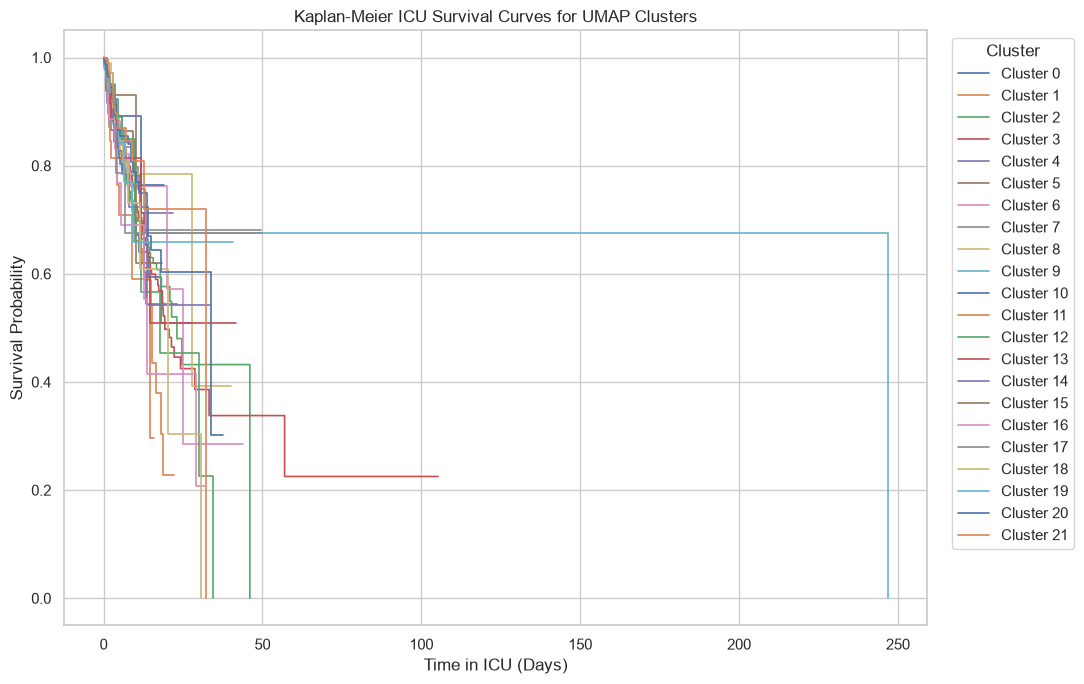

In [28]:
# Create the Kaplan-Meier estimator
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(
    figsize=(11, 7)
)

# Draw one survival curve for every cluster
for cluster in sorted(
    survival_data["cluster"].unique()
):

    cluster_data = survival_data[
        survival_data["cluster"] == cluster
    ]

    kmf.fit(
        durations=cluster_data["icu_los_days"],
        event_observed=cluster_data["icu_mortality"],
        label=f"Cluster {cluster}"
    )

    # Confidence intervals are hidden because
    # many clusters are shown together
    kmf.plot_survival_function(
        ax=ax,
        ci_show=False,
        linewidth=1.2
    )

ax.set_title(
    "Kaplan-Meier ICU Survival Curves for UMAP Clusters"
)

ax.set_xlabel("Time in ICU (Days)")
ax.set_ylabel("Survival Probability")

ax.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Save the plot
plt.savefig(
    PLOTS_DIR / "umap_kaplan_meier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Creates Kaplan-Meier survival curves for each of the $22$ UMAP-DBSCAN sepsis clusters using ICU length of stay as the time variable.
- ICU mortality is used as the event indicator, allowing the survival probability of patients to be tracked during their ICU stay.
- A separate survival curve is generated for every cluster, making it possible to visually compare survival patterns across the identified patient subgroups.
- Confidence intervals are hidden to keep the figure readable because a large number of clusters are displayed together.
- Overall, this block provides a visual comparison of ICU survival experience across the $22$ sepsis clusters and saves the Kaplan-Meier plot for reporting.

### Perform the Global Log-Rank Test

In [29]:
# Test whether survival differs across the clusters
logrank_result = multivariate_logrank_test(
    survival_data["icu_los_days"],
    survival_data["cluster"],
    survival_data["icu_mortality"]
)

print(
    "Patients:",
    len(survival_data)
)

print(
    "Clusters:",
    survival_data["cluster"].nunique()
)

print(
    "ICU deaths:",
    int(
        survival_data["icu_mortality"].sum()
    )
)

print(
    "Log-rank statistic:",
    round(
        logrank_result.test_statistic,
        4
    )
)

print(
    "Log-rank p-value:",
    logrank_result.p_value
)

Patients: 7123
Clusters: 22
ICU deaths: 912
Log-rank statistic: 21.9453
Log-rank p-value: 0.40266683518639335


#### Observation :
- Applies a multivariate log-rank test to determine whether ICU survival differs significantly across the $22$ sepsis clusters.
- The test includes $7,123$ patients and $912$ ICU deaths, matching the population used in the Kaplan-Meier analysis.
- The log-rank statistic is $21.9453$ with a p-value of $0.4027$.
- Since the p-value is greater than $0.05$, there is no statistically significant difference in ICU survival across the $22$ clusters.
- Overall, although the Kaplan-Meier curves may show some visual variation, the survival differences between the identified sepsis subgroups are not statistically significant.

## Clinical Interpretation

### Add Cluster Labels to the Clustering Features

In [30]:
# Copy the original scaled clustering features
cluster_features = scaled_df[
    [ID_COL] + feature_cols
].copy()

# Add UMAP DBSCAN cluster labels
cluster_features["cluster"] = (
    umap_results["cluster"].values
)

# Remove DBSCAN outliers
cluster_features = cluster_features[
    cluster_features["cluster"] != -1
].copy()

print(
    "Patients used for interpretation:",
    len(cluster_features)
)

print(
    "Clusters:",
    cluster_features["cluster"].nunique()
)

Patients used for interpretation: 7123
Clusters: 22


#### Observation :
- Combines the original $80$ scaled clinical features with the corresponding UMAP-DBSCAN cluster labels for each ICU stay.
- Removes the DBSCAN outliers ($-1$) so that only patients assigned to a valid cluster are included in the clinical interpretation.
- A total of $7,123$ patients across $22$ clusters are retained for further feature-level analysis.
- Overall, this block prepares the clustered patient-feature dataset needed to determine which clinical characteristics distinguish the identified sepsis subgroups.

### Standardize Features for Interpretation

The clustering features are already Min-Max scaled.

For clinical interpretation only, the features are standardized again so that cluster averages can be compared on the same scale.

A standardized value:

- Around 0 means close to the overall patient average.
- Above 0 means higher than the overall patient average.
- Below 0 means lower than the overall patient average.

This additional standardization does not change the clustering result.

In [31]:
# Calculate the overall mean of every feature
feature_mean = X.mean()

# Calculate the overall standard deviation
feature_std = X.std()

# Avoid division by zero for constant features
feature_std = feature_std.replace(
    0,
    np.nan
)

# Standardize the features
X_standardized = (
    X - feature_mean
) / feature_std

# Add cluster labels
X_standardized["cluster"] = (
    umap_results["cluster"].values
)

# Remove DBSCAN outliers
X_standardized = X_standardized[
    X_standardized["cluster"] != -1
]

X_standardized.head()

,age,gender,admissionheight,admissionweight,min_BUN,min_Hgb,min_WBC x 1000,min_anion gap,min_bicarbonate,min_chloride,...,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU,cluster
0,0.043316,1.014687,-0.232191,0.123306,-0.744668,-1.132370,-0.684715,-0.140295,0.387933,-0.312693,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428,0
1,-0.826669,-0.985397,-0.411240,-0.409269,-0.914413,0.510064,-0.966577,-0.353228,0.387933,-1.011505,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428,1
2,1.037584,1.014687,-0.962713,-0.349726,0.613290,-0.099983,-0.812008,1.563175,-0.154015,0.805407,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428,2
3,0.354024,1.014687,-0.053141,0.080303,-0.914413,2.293277,0.351810,2.201976,-1.057262,-0.452455,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428,2
4,-0.329535,-0.985397,1.221691,0.821277,-1.084158,0.979330,-0.339207,0.924374,-0.334664,-1.291030,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428,3


#### Observation :
- Standardizes all $80$ clustering features using their overall mean and standard deviation so that cluster profiles can be compared on the same scale.
- After standardization, a value above $0$ means the feature is higher than the overall patient average, while a value below $0$ means it is lower than average.
- Adds the corresponding UMAP-DBSCAN cluster labels and removes the DBSCAN outliers before cluster-level interpretation.
- This transformation makes it easier to identify which clinical characteristics are relatively high or low within each sepsis subgroup, regardless of the original measurement scale.

### Calculate Mean Cluster Feature Profiles

In [32]:
# Calculate the average standardized value
# of every feature within every cluster
cluster_profiles = (
    X_standardized
    .groupby("cluster")
    .mean()
)

print(
    "Cluster profile shape:",
    cluster_profiles.shape
)

cluster_profiles.head()

Cluster profile shape: (22, 80)


,age,gender,admissionheight,admissionweight,min_BUN,min_Hgb,min_WBC x 1000,min_anion gap,min_bicarbonate,min_chloride,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.120475,1.014687,-0.474723,-0.107700,-0.017713,-0.148344,0.091100,-0.049798,-0.164453,0.077089,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428
1,0.124386,-0.985397,0.545514,0.289527,0.157589,0.153124,0.040306,-0.164158,-0.014894,-0.063289,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428
2,0.075066,1.014687,-0.508102,-0.192795,-0.106555,-0.094012,0.024335,0.055100,-0.019620,-0.010021,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428
3,0.063932,-0.985397,0.555472,0.224321,0.074749,0.183363,-0.008044,-0.045455,0.098232,-0.102721,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428
4,-0.049540,-0.985397,0.668325,0.379765,0.045035,-0.028245,-0.068548,-0.179455,0.073769,-0.034774,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,-1.466164,-0.155241,5.936484


#### Observation :
- Calculates the average standardized value of all $80$ clinical features within each of the $22$ clusters.
- The resulting profile table has a shape of $22 \times 80$, meaning every cluster is summarized across all selected clustering features.
- Positive values indicate that a feature is higher than the overall cohort average, while negative values indicate that it is lower.
- These cluster-level profiles make it possible to identify the clinical characteristics that define and differentiate each sepsis subgroup.

### Identify the Most Distinguishing Features

In [33]:
# Calculate how much every feature changes across clusters
feature_variation = (
    cluster_profiles
    .std(axis=0)
    .sort_values(ascending=False)
)

# Keep the 15 features that differ most across clusters
top_profile_features = (
    feature_variation
    .head(15)
    .index
    .tolist()
)

print("Top 15 distinguishing features:")

for feature in top_profile_features:
    print(feature)

Top 15 distinguishing features:
ethnicity_Asian
unittype_Neuro ICU
ethnicity_Native American
unittype_SICU
ethnicity_Hispanic
ethnicity_Other/Unknown
ethnicity_African American
ethnicity_Caucasian
unittype_CCU-CTICU
unittype_Cardiac ICU
unittype_MICU
unittype_Med-Surg ICU
gender
admissionheight
admissionweight


#### Observation :
- Calculates how much each of the $80$ clinical features varies across the $22$ patient clusters using the standard deviation of the cluster profiles.
- Selects the $15$ features with the greatest variation, identifying the variables that most strongly distinguish one sepsis subgroup from another.
- The most distinguishing variables are mainly related to ethnicity, ICU type, gender, admission height, and admission weight.
- Overall, this block identifies the key characteristics that contribute most to the clinical differences between the UMAP-DBSCAN sepsis clusters.

### Plot the Clincal Feature Heatmap

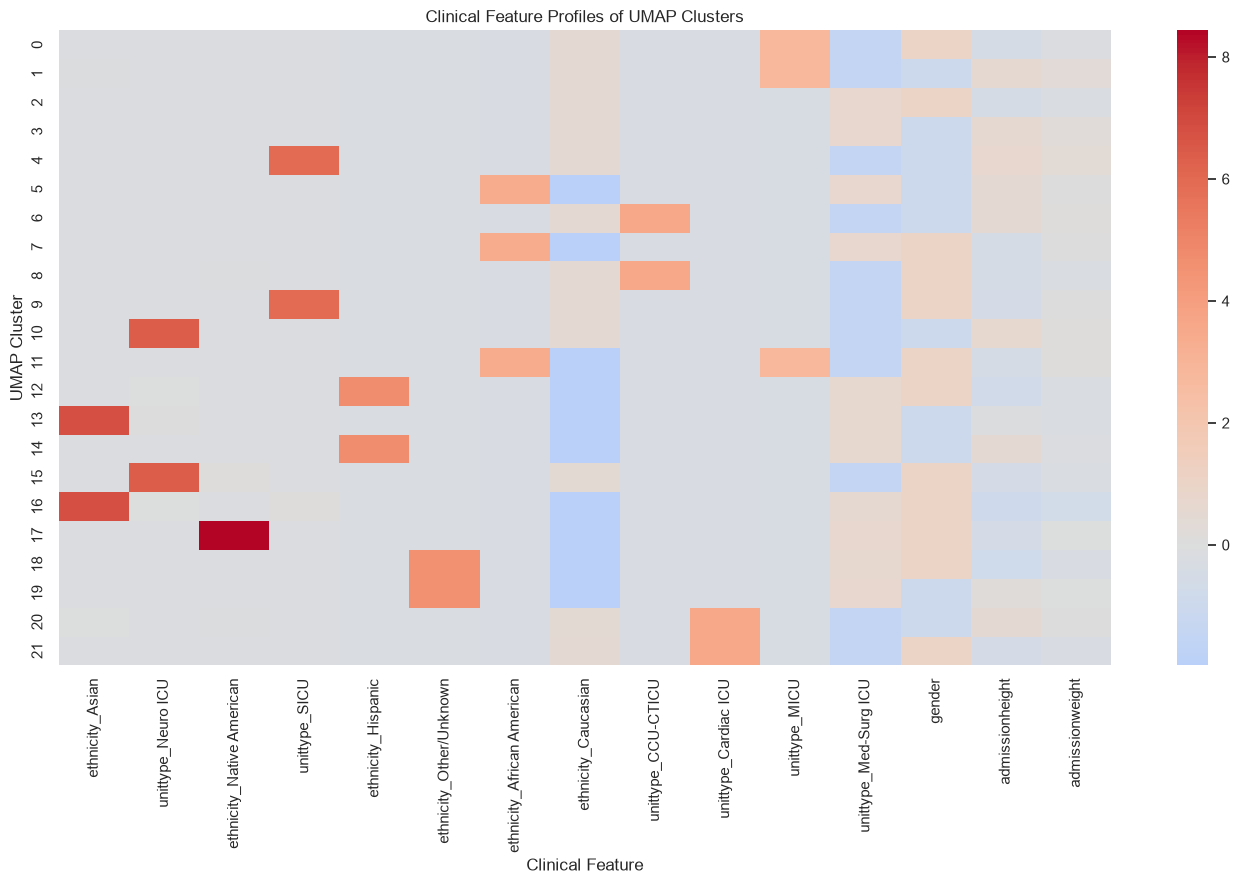

In [34]:
plt.figure(figsize=(14, 9))

# Show whether important clinical features are relatively high or low in each cluster
sns.heatmap(
    cluster_profiles[
        top_profile_features
    ],
    cmap="coolwarm",
    center=0
)

plt.title(
    "Clinical Feature Profiles of UMAP Clusters"
)

plt.xlabel("Clinical Feature")
plt.ylabel("UMAP Cluster")

plt.tight_layout()

# Save the plot
plt.savefig(
    PLOTS_DIR / "umap_cluster_feature_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Creates a heatmap of the $15$ most distinguishing clinical features across all $22$ UMAP-DBSCAN clusters.
- The color scale is centered at $0$, so higher-than-average and lower-than-average feature values can be identified easily for each cluster.
- The heatmap shows that the clusters differ mainly in ethnicity, ICU type, gender, admission height, and admission weight.
- Overall, this block provides a clear visual summary of the clinical characteristics that differentiate the sepsis patient subgroups.

## Save Essential Results

### Save UMAP Cluster Assignments

In [35]:
# Save patient IDs, UMAP coordinates, and DBSCAN cluster labels
umap_results.to_csv(
    RESULTS_DIR / "umap_dbscan_clusters.csv",
    index=False
)

print(
    "Saved: umap_dbscan_clusters.csv"
)

Saved: umap_dbscan_clusters.csv


### Save Internal Evaluation Summary

In [36]:
# Save the clustering evaluation results
evaluation_summary.to_csv(
    RESULTS_DIR / "umap_evaluation_summary.csv",
    index=False
)

print(
    "Saved: umap_evaluation_summary.csv"
)

Saved: umap_evaluation_summary.csv


### Save Clinical Outcome Summary

In [37]:
# Save clinical characteristics of every cluster
clinical_summary.to_csv(
    RESULTS_DIR / "umap_clinical_summary.csv",
    index=False
)

print(
    "Saved: umap_clinical_summary.csv"
)

Saved: umap_clinical_summary.csv


### Verify Saved Files

In [38]:
print("Saved result files:")
print()

for file in sorted(RESULTS_DIR.glob("*.csv")):
    print(file.name)

print()
print("Saved plot files:")
print()

for file in sorted(PLOTS_DIR.glob("*.png")):
    print(file.name)

Saved result files:

umap_clinical_summary.csv
umap_dbscan_clusters.csv
umap_evaluation_summary.csv

Saved plot files:

umap_cluster_feature_heatmap.png
umap_dbscan_clusters.png
umap_hospital_mortality.png
umap_kaplan_meier.png
umap_representation.png


## Final Summary

In [39]:
print("UMAP + DBSCAN Final Summary")
print("=" * 45)


print()
print("Dataset")

print(
    "Patients:",
    len(umap_results)
)

print(
    "Clustering features:",
    len(feature_cols)
)


print()
print("UMAP Parameters")

print(
    "Dimensions:",
    UMAP_COMPONENTS
)

print(
    "n_neighbors:",
    UMAP_N_NEIGHBORS
)

print(
    "min_dist:",
    UMAP_MIN_DIST
)

print(
    "Metric:",
    UMAP_METRIC
)

print(
    "Random state:",
    RANDOM_STATE
)


print()
print("DBSCAN Parameters")

print(
    "Epsilon:",
    DBSCAN_EPS
)

print(
    "Min samples:",
    DBSCAN_MIN_SAMPLES
)


print()
print("Clustering Result")

print(
    "Clusters:",
    n_clusters
)

print(
    "Outliers:",
    n_outliers
)

print(
    "Outlier percentage:",
    round(outlier_percentage, 2),
    "%"
)


print()
print("Internal Evaluation")

print(
    "Silhouette Score:",
    round(silhouette, 4)
)

print(
    "Davies-Bouldin Index:",
    round(dbi, 4)
)

print(
    "Calinski-Harabasz Index:",
    round(chi, 2)
)


print()
print("Survival Evaluation")

print(
    "Patients:",
    len(survival_data)
)

print(
    "ICU deaths:",
    int(
        survival_data["icu_mortality"].sum()
    )
)

print(
    "Log-rank statistic:",
    round(
        logrank_result.test_statistic,
        4
    )
)

print(
    "Log-rank p-value:",
    logrank_result.p_value
)

UMAP + DBSCAN Final Summary

Dataset
Patients: 7648
Clustering features: 80

UMAP Parameters
Dimensions: 2
n_neighbors: 10
min_dist: 0.1
Metric: euclidean
Random state: 42

DBSCAN Parameters
Epsilon: 0.35
Min samples: 50

Clustering Result
Clusters: 22
Outliers: 525
Outlier percentage: 6.86 %

Internal Evaluation
Silhouette Score: 0.8867
Davies-Bouldin Index: 0.0984
Calinski-Harabasz Index: 64673.27

Survival Evaluation
Patients: 7123
ICU deaths: 912
Log-rank statistic: 21.9453
Log-rank p-value: 0.40266683518639335


## Final Workflow

```
feature_data_scaled.csv
          ↓
       UMAP 2-D
          ↓
 n_neighbors = 10
 min_dist = 0.1
          ↓
       DBSCAN
          ↓
 eps = 0.35
 min_samples = 50
          ↓
 ┌────────┴─────────┐
 ↓                  ↓
Internal         Cluster
Evaluation       Visualization
 ↓
Compare with Ju and Dubin
 ↓
Clinical Outcomes
 ↓
Hospital Mortality
 ↓
Kaplan-Meier Survival
 ↓
Log-Rank Test
 ↓
Clinical Feature Profiles
 ↓
Feature Heatmap
 ↓
Save Essential Results
```

## Parameter Comparison

| Method | Parameter              | Ju and Dubin                                             | My Parameter    |
| ------ | ---------------------- | -------------------------------------------------------- | --------------- |
| UMAP   | Input scaling          | Min-Max scaling                                          | Min-Max scaling |
| UMAP   | Distance metric        | Euclidean                                                | Euclidean       |
| UMAP   | Embedding dimensions   | 2                                                        | 2               |
| UMAP   | `n_neighbors`          | Not reported                                             | 10              |
| UMAP   | `min_dist`             | Not reported                                             | 0.1             |
| UMAP   | Random seed            | Not reported                                             | 42              |
| DBSCAN | Epsilon `ε`            | Selected using k-distance knee, exact value not reported | 0.35            |
| DBSCAN | `min_samples` / MinPts | 50                                                       | 50              |
